Epoch 1/100, Loss: 111.3416
Epoch 2/100, Loss: 2.1163
Epoch 3/100, Loss: 2.4319
Epoch 4/100, Loss: 0.1381
Epoch 5/100, Loss: 0.1279
Epoch 6/100, Loss: 0.1941
Epoch 7/100, Loss: 0.1192
Epoch 8/100, Loss: 0.1971
Epoch 9/100, Loss: 0.4136
Epoch 10/100, Loss: 0.1049
Epoch 11/100, Loss: 0.1894
Epoch 12/100, Loss: 0.1566
Epoch 13/100, Loss: 0.2067
Epoch 14/100, Loss: 0.1047
Epoch 15/100, Loss: 0.1341
Epoch 16/100, Loss: 0.4597
Epoch 17/100, Loss: 0.1983
Epoch 18/100, Loss: 0.0874
Epoch 19/100, Loss: 0.0840
Epoch 20/100, Loss: 0.0843
Epoch 21/100, Loss: 0.2079
Epoch 22/100, Loss: 0.1213
Epoch 23/100, Loss: 0.0761
Epoch 24/100, Loss: 0.0771
Epoch 25/100, Loss: 0.0787
Epoch 26/100, Loss: 0.0728
Epoch 27/100, Loss: 0.0695
Epoch 28/100, Loss: 0.0671
Epoch 29/100, Loss: 0.0674
Epoch 30/100, Loss: 0.0727
Epoch 31/100, Loss: 0.0701
Epoch 32/100, Loss: 0.0644
Epoch 33/100, Loss: 0.0972
Epoch 34/100, Loss: 0.0725
Epoch 35/100, Loss: 0.0628
Epoch 36/100, Loss: 0.0675
Epoch 37/100, Loss: 0.0619
Epoch 38

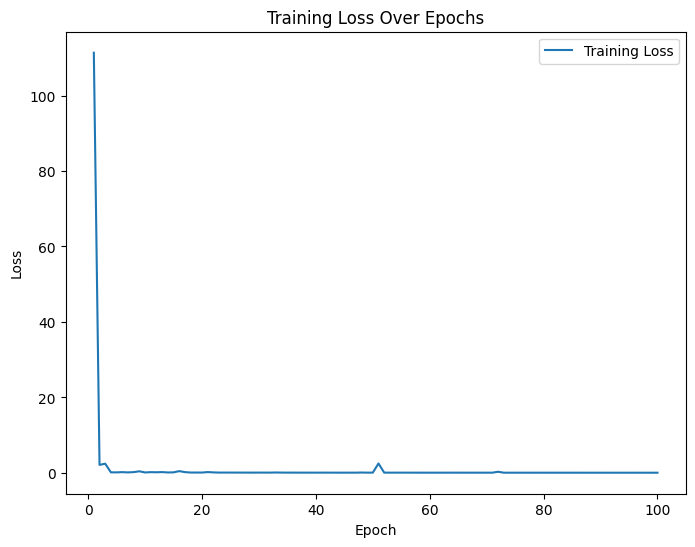

Best XGB parameters found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
XGBoost regressor performance on test set: MAE = 0.2827
XGB model saved to MCCX-0_283T38.pkl
Scatter data saved to MCCX-0_283T38.csv


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
np.set_printoptions(precision=6)
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, ParameterGrid
import random
import matplotlib.pyplot as plt  # for plotting training loss
import pickle
import os

# set random seed for reproducibility
seed = 0
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 1. data preparation
# ------------------------------
def load_CSN_data():
    csv_path = '../../CSN_Viability_Database_2025.csv'
    return pd.read_csv(csv_path)

CSN = load_CSN_data()
CSN = CSN.drop(['Example ID', 'Source', 'Figure ID', 'Data Provider', 'PI',
                'Date Received', 'Data Measurment Published', 'Prior Exposure', 'Comments', 'Error'], axis=1)

CSN_prepared = pd.get_dummies(CSN, dtype=int)
CSN_prepared['Surface Area per Liter'] = CSN_prepared['Surface Area (NMC) (m2/g)'] * CSN_prepared['Concentration (mg/L)']
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)
CSN_prepared['log Concentration'] = np.log10(CSN_prepared['Concentration (mg/L)'] + 1e-9)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

# T38
CSN_new = CSN_prepared[-38:]
CSN_prepared = CSN_prepared.drop(CSN_prepared.index[-38:])
X_train = CSN_prepared.drop(['Viability_Fraction'], axis=1)
y_train = CSN_prepared['Viability_Fraction']

X_test = CSN_new.drop(['Viability_Fraction'], axis=1)
y_test = CSN_new['Viability_Fraction']

# define custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# 2. define a 1D CNN model
# ------------------------------
class CNN(nn.Module):
    def __init__(self, num_features, feature_dim=128):
        super(CNN, self).__init__()
        # Input shape: (batch_size, 1, num_features)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Output: (16, num_features)
        self.pool1 = nn.MaxPool1d(kernel_size=2)  # Output: (16, num_features//2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)  # Output: (32, num_features//2)
        self.pool2 = nn.MaxPool1d(kernel_size=2)  # Output: (32, num_features//4)
        self.flatten = nn.Flatten()
        conv_out_size = num_features // 4
        self.fc1 = nn.Linear(32 * conv_out_size, feature_dim)  # get 128 features
        self.fc2 = nn.Linear(feature_dim, 1)  # regression output

    def forward(self, x, feature_extract=False):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        features = F.relu(self.fc1(x))
        if feature_extract:
            return features
        out = self.fc2(features)
        return out

num_features = X_train.shape[1]
model = CNN(num_features=num_features, feature_dim=128).to(device)

# ------------------------------
# 3. train the CNN model
# ------------------------------
criterion = nn.MSELoss()  # mean squared error loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100

train_losses = []  # list to store training loss for each epoch

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)  # record training loss
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

model.eval()

# Save CNN model weights for future prediction without retraining
torch.save(model.state_dict(), 'cnn_model_weights.pth')
print("CNN model weights saved to cnn_model_weights.pth")

# Plot the training loss graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.show()

# ------------------------------
# 4. extract features directly from raw features (bypass model)
# ------------------------------
def extract_features(loader):
    features_list = []
    targets_list = []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            feats = model(data, feature_extract=True)  # extract features
            features_list.append(feats.cpu().numpy())
            targets_list.append(target.cpu().numpy())
    features = np.concatenate(features_list, axis=0)
    targets = np.concatenate(targets_list, axis=0).flatten()
    return features, targets

train_features, train_targets = extract_features(train_loader)
test_features, test_targets = extract_features(test_loader)

# ------------------------------
# 5. hyperparameter tuning for XGBoost
# ------------------------------
# define a parameter grid for XGBoost
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [7],
}

num_iterations = 10
best_params = None
best_score = float('inf')

for params in ParameterGrid(param_grid):
    scores = []
    weights = []
    for _ in range(num_iterations):
        test_size = random.uniform(0.1, 0.3)
        X_train_mccv, X_val, y_train_mccv, y_val = train_test_split(
            train_features, train_targets, test_size=test_size, random_state=np.random.randint(0, 10000)
        )
        model_cv = XGBRegressor(objective='reg:squarederror', **params)
        model_cv.fit(X_train_mccv, y_train_mccv)
        
        y_val_pred = model_cv.predict(X_val)
        score = mean_absolute_error(y_val, y_val_pred)
        scores.append(score)
        # use the number of samples in the validation set as weights
        weights.append(len(y_val))
    
    weighted_avg_score = np.average(scores, weights=weights)
    if weighted_avg_score < best_score:
        best_score = weighted_avg_score
        best_params = params

print("Best XGB parameters found:", best_params)

# ------------------------------
# 6. use the best XGBoost model to predict test set
# ------------------------------
reg = XGBRegressor(objective='reg:squarederror', random_state=seed, **best_params)
reg.fit(train_features, train_targets)
y_pred_test = reg.predict(test_features)
test_mae = mean_absolute_error(test_targets, y_pred_test)
print("XGBoost regressor performance on test set: MAE = {:.4f}".format(test_mae))

# ------------------------------
# 7. Save the final XGBoost model using pickle
# ------------------------------
with open('MCCX-0_283T38.pkl', 'wb') as f:
    pickle.dump(reg, f)
print("XGB model saved to MCCX-0_283T38.pkl")

# Create a DataFrame with experimental values and predicted values
scatter_data = pd.DataFrame({
    "Experimental Values": test_targets,
    "Predicted Values": y_pred_test
})
# Save the DataFrame to a CSV file
scatter_data.to_csv("MCCX-0_283T38.csv", index=False)
print("Scatter data saved to MCCX-0_283T38.csv")


In [4]:
# ------------------------------
# 8. use the best XGBoost model with 100 random seeds and evaluate
# ------------------------------
mae_list = []

# Generate 100 unique random seeds between 0 and 100000
random_seeds = random.sample(range(0, 100000), 100)

for seed in random_seeds:
    reg = XGBRegressor(
        objective='reg:squarederror',
        random_state=seed,
        subsample=0.8,             # add sample random sampling
        colsample_bytree=0.8,      # add feature random sampling
        colsample_bylevel=0.8,     # add another layer of feature randomness
        **best_params
    )
    reg.fit(train_features, train_targets)
    y_pred_test = reg.predict(test_features)
    test_mae = mean_absolute_error(test_targets, y_pred_test)
    mae_list.append(test_mae)
    print(f"Seed {seed}: MAE = {test_mae:.4f}")

mae_array = np.array(mae_list)
print("\nSummary of XGBoost predictions over 100 random seeds:")
print("Mean MAE: {:.4f} ± {:.4f}".format(mae_array.mean(), mae_array.std()))
print("Min MAE: {:.4f}".format(mae_array.min()))
print("Max MAE: {:.4f}".format(mae_array.max()))


Seed 28631: MAE = 0.2612
Seed 66150: MAE = 0.2413
Seed 18254: MAE = 0.2773
Seed 36941: MAE = 0.2434
Seed 18316: MAE = 0.2505
Seed 99064: MAE = 0.2753
Seed 12429: MAE = 0.2659
Seed 81050: MAE = 0.2440
Seed 32834: MAE = 0.2343
Seed 69804: MAE = 0.2373
Seed 92428: MAE = 0.2600
Seed 78892: MAE = 0.2344
Seed 19262: MAE = 0.2580
Seed 40651: MAE = 0.2503
Seed 12945: MAE = 0.2465
Seed 95660: MAE = 0.2695
Seed 9665: MAE = 0.2215
Seed 89651: MAE = 0.2797
Seed 43279: MAE = 0.2600
Seed 61884: MAE = 0.2559
Seed 73375: MAE = 0.2898
Seed 13199: MAE = 0.2643
Seed 46372: MAE = 0.2583
Seed 56907: MAE = 0.2659
Seed 41444: MAE = 0.2479
Seed 80070: MAE = 0.2689
Seed 83941: MAE = 0.2714
Seed 26801: MAE = 0.2973
Seed 72420: MAE = 0.2772
Seed 62522: MAE = 0.2688
Seed 58024: MAE = 0.2516
Seed 68334: MAE = 0.2641
Seed 34143: MAE = 0.2763
Seed 8163: MAE = 0.2318
Seed 71919: MAE = 0.2929
Seed 1840: MAE = 0.2422
Seed 12225: MAE = 0.2821
Seed 94333: MAE = 0.2696
Seed 52274: MAE = 0.2205
Seed 93094: MAE = 0.2998
See